In [48]:
import sys
print(sys.executable)


c:\Users\agarc\OneDrive\Escritorio\GAT+LINUCB\.venv\Scripts\python.exe


In [ ]:
from IPython.display import display
%matplotlib inline


# BLOQUE 4 — Visualización de LinUCB (Embeddings vs X_raw)

Este notebook carga los `logs_*.csv` y `summary.json` generados por:

- `python -m src.10_linucb_contextual --context embeddings`
- `python -m src.10_linucb_contextual --context X_raw`

y produce visualizaciones comparables:

- Regret empírico acumulado  
- Reward acumulado  
- Distribución de acciones  
- Evolución de ||θ_t||

> Nota: este notebook **no ejecuta lógica de decisión**, solo análisis.


In [50]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [51]:
from pathlib import Path
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [52]:
from pathlib import Path
import os, glob

def find_project_root(markers=("artifacts", "src")) -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):  # sube hasta 8 niveles
        if all((p / m).exists() for m in markers):
            return p
        p = p.parent
    raise FileNotFoundError(f"No encontré la raíz del proyecto desde {Path.cwd()}")

ROOT = find_project_root()
ART = ROOT / "artifacts" / "linucb"

print("CWD :", Path.cwd())
print("ROOT:", ROOT)
print("ART :", ART)
print("exists ART?", ART.exists())
print("emb runs found:", len(glob.glob(str(ART / 'run_embeddings_*'))))
print("xraw runs found:", len(glob.glob(str(ART / 'run_X_raw_*'))))


CWD : c:\Users\agarc\OneDrive\Escritorio\GAT+LINUCB\notebooks
ROOT: C:\Users\agarc\OneDrive\Escritorio\GAT+LINUCB
ART : C:\Users\agarc\OneDrive\Escritorio\GAT+LINUCB\artifacts\linucb
exists ART? True
emb runs found: 1
xraw runs found: 2


In [53]:
run_emb = latest_run_dir("run_embeddings_")
run_xraw = latest_run_dir("run_X_raw_")

print("Embeddings run:", run_emb)
print("X_raw run:", run_xraw)


Embeddings run: C:\Users\agarc\OneDrive\Escritorio\GAT+LINUCB\artifacts\linucb\run_embeddings_20251230_134630
X_raw run: C:\Users\agarc\OneDrive\Escritorio\GAT+LINUCB\artifacts\linucb\run_X_raw_20251230_135803


In [54]:
ROOT = Path(".")
ART = ROOT / "artifacts" / "linucb"

def latest_run_dir(prefix: str) -> Path:
    runs = sorted([Path(p) for p in glob.glob(str(ART / f"{prefix}*"))])
    if not runs:
        raise FileNotFoundError(f"No runs with prefix {prefix}")
    return runs[-1]

def load_run(run_dir: Path):
    with open(run_dir / "summary.json", "r", encoding="utf-8") as f:
        summary = json.load(f)
    logs = {}
    for pol in ["linucb", "greedy", "random"]:
        logs[pol] = pd.read_csv(run_dir / f"logs_{pol}.csv")
    return summary, logs


In [55]:
from IPython.display import display


In [56]:
summ_emb, logs_emb = load_run(run_emb)
summ_xraw, logs_xraw = load_run(run_xraw)


In [57]:
def pretty_summary(summary):
    rows = []
    for r in summary["runs"]:
        rows.append({
            "policy": r["policy"],
            "d": r["d"],
            "cum_reward": r["cum_reward"],
            "cum_regret_emp": r["cum_regret_emp"],
            "repeat_rate": r["repeat_rate"],
        })
    return pd.DataFrame(rows).sort_values("policy")

display(pretty_summary(summ_emb))
display(pretty_summary(summ_xraw))


,policy,d,cum_reward,cum_regret_emp,repeat_rate
1,greedy,16,-0.427160,17.067072,0.435065
0,linucb,16,1.131789,15.508124,0.363636
2,random,16,0.246547,16.393365,0.012987


,policy,d,cum_reward,cum_regret_emp,repeat_rate
1,greedy,2,2.190289,14.449624,0.701299
0,linucb,2,0.995007,15.644906,0.577922
2,random,2,0.246547,16.393365,0.012987


## 1️⃣ Sanity check — causalidad (date_t → date_reward)


In [58]:
def show_dates(df, n=8):
    return df[["date_t", "date_reward"]].head(n)

display(show_dates(logs_emb["linucb"]))
display(show_dates(logs_xraw["linucb"]))


,date_t,date_reward
0,2023-01-06,2023-01-13
1,2023-01-13,2023-01-20
2,2023-01-20,2023-01-27
3,2023-01-27,2023-02-03
4,2023-02-03,2023-02-10
5,2023-02-10,2023-02-17
6,2023-02-17,2023-02-24
7,2023-02-24,2023-03-03


,date_t,date_reward
0,2023-01-06,2023-01-13
1,2023-01-13,2023-01-20
2,2023-01-20,2023-01-27
3,2023-01-27,2023-02-03
4,2023-02-03,2023-02-10
5,2023-02-10,2023-02-17
6,2023-02-17,2023-02-24
7,2023-02-24,2023-03-03


## 2️⃣ Regret empírico acumulado


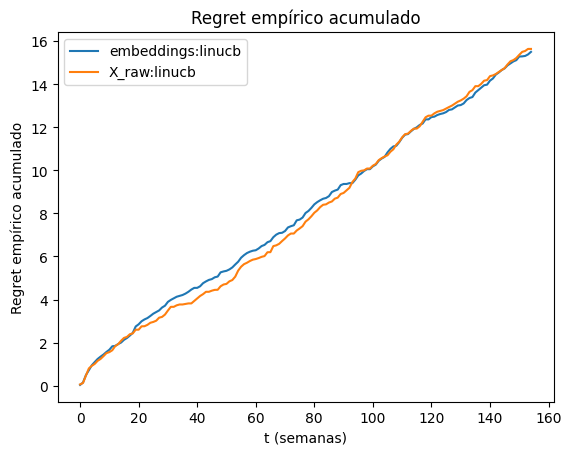

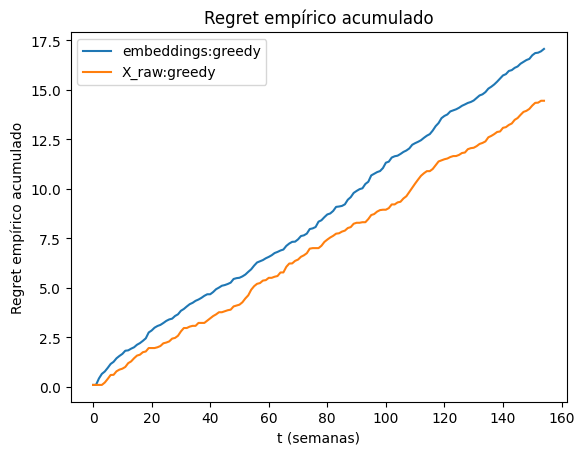

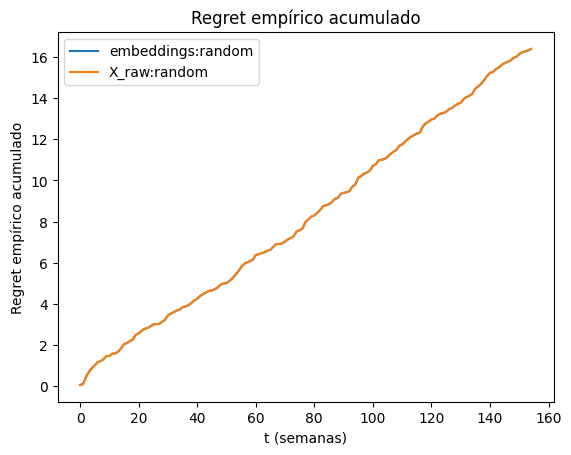

In [59]:
def plot_cum_regret(logs_a, logs_b, label_a, label_b, policy="linucb"):
    plt.figure()
    plt.plot(logs_a[policy]["cum_regret_emp"], label=f"{label_a}:{policy}")
    plt.plot(logs_b[policy]["cum_regret_emp"], label=f"{label_b}:{policy}")
    plt.xlabel("t (semanas)")
    plt.ylabel("Regret empírico acumulado")
    plt.title("Regret empírico acumulado")
    plt.legend()
    plt.show()

plot_cum_regret(logs_emb, logs_xraw, "embeddings", "X_raw", "linucb")
plot_cum_regret(logs_emb, logs_xraw, "embeddings", "X_raw", "greedy")
plot_cum_regret(logs_emb, logs_xraw, "embeddings", "X_raw", "random")


## 3️⃣ Reward acumulado


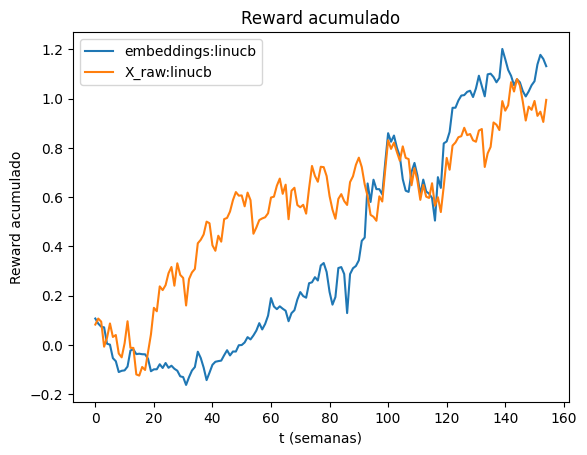

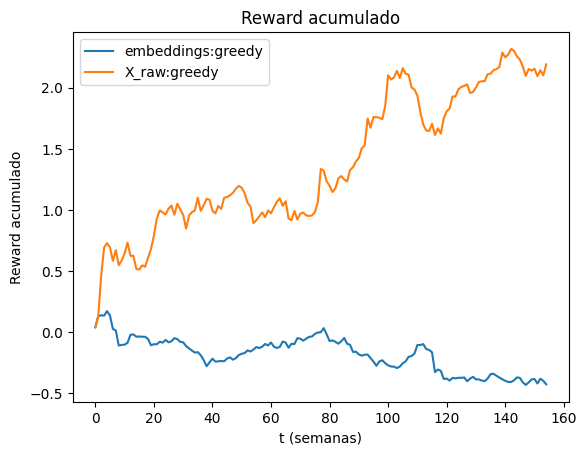

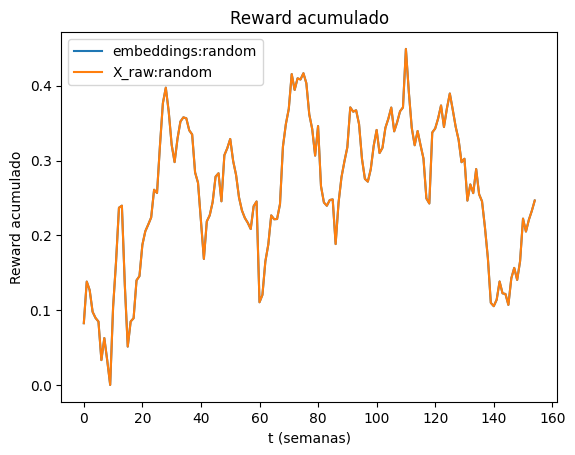

In [60]:
def plot_cum_reward(logs_a, logs_b, label_a, label_b, policy="linucb"):
    plt.figure()
    plt.plot(logs_a[policy]["cum_reward"], label=f"{label_a}:{policy}")
    plt.plot(logs_b[policy]["cum_reward"], label=f"{label_b}:{policy}")
    plt.xlabel("t (semanas)")
    plt.ylabel("Reward acumulado")
    plt.title("Reward acumulado")
    plt.legend()
    plt.show()

plot_cum_reward(logs_emb, logs_xraw, "embeddings", "X_raw", "linucb")
plot_cum_reward(logs_emb, logs_xraw, "embeddings", "X_raw", "greedy")
plot_cum_reward(logs_emb, logs_xraw, "embeddings", "X_raw", "random")


## 4️⃣ Distribución de acciones (exploración vs colapso)


In [61]:
def top_actions(df, k=10):
    vc = df["asset"].value_counts().head(k)
    out = vc.reset_index()
    out.columns = ["asset", "count"]
    out["share"] = out["count"] / len(df)
    return out

display(top_actions(logs_emb["linucb"]))
display(top_actions(logs_xraw["linucb"]))


,asset,count,share
0,TSLA,37,0.238710
1,AVGO,17,0.109677
2,NVDA,16,0.103226
3,PEP,12,0.077419
4,KO,11,0.070968
5,PG,9,0.058065
6,JNJ,7,0.045161
7,NVS,7,0.045161
8,AMZN,3,0.019355
9,NSRGY,3,0.019355


,asset,count,share
0,TSLA,72,0.464516
1,BABA,19,0.122581
2,NVDA,18,0.116129
3,NVO,14,0.090323
4,UNH,11,0.070968
5,AVGO,10,0.064516
6,BA,3,0.019355
7,LLY,3,0.019355
8,ASML,3,0.019355
9,FMX,1,0.006452


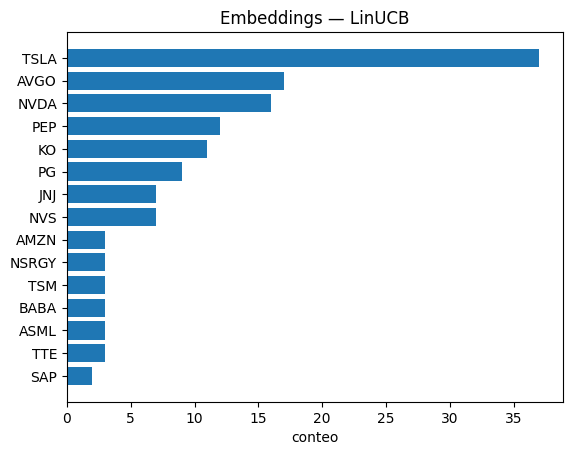

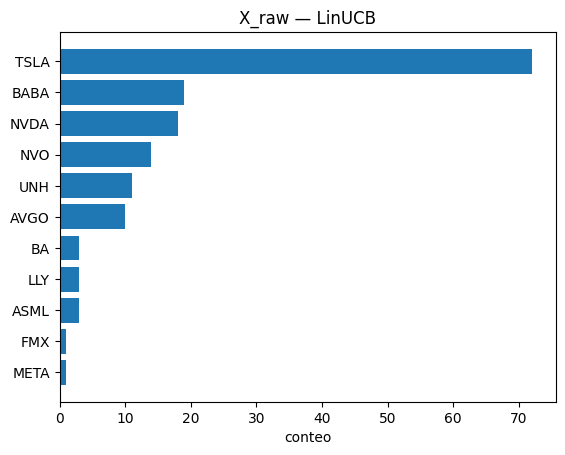

In [62]:
def plot_action_hist(df, title, k=15):
    vc = df["asset"].value_counts().head(k)[::-1]
    plt.figure()
    plt.barh(vc.index, vc.values)
    plt.xlabel("conteo")
    plt.title(title)
    plt.show()

plot_action_hist(logs_emb["linucb"], "Embeddings — LinUCB")
plot_action_hist(logs_xraw["linucb"], "X_raw — LinUCB")


## 5️⃣ Evolución de la norma del parámetro (||θ_t||)


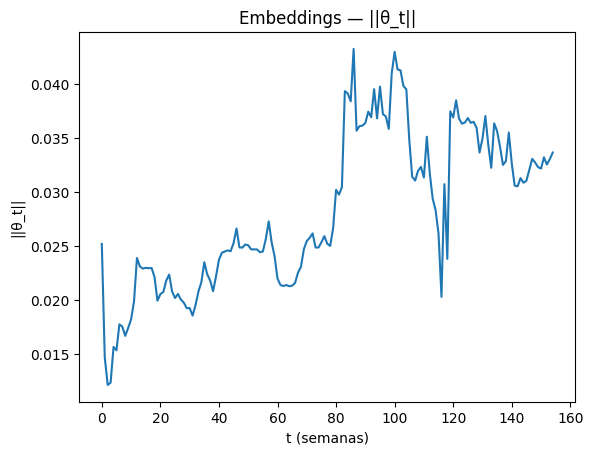

Embeddings: (0.0121722230129141, 0.0259287060681231, 0.0432420918362043)


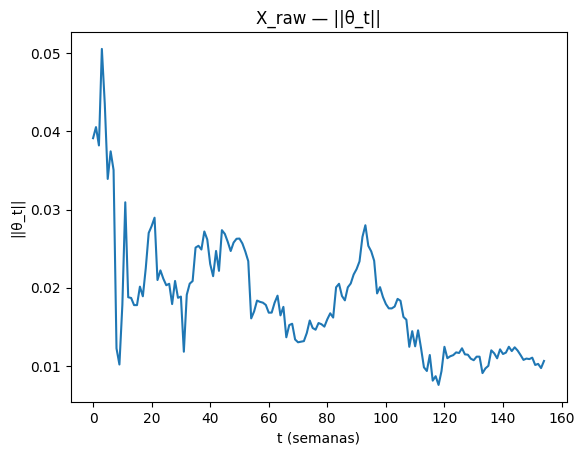

X_raw: (0.0075551960785645, 0.0175846846576992, 0.0505546843122599)


In [63]:
def plot_theta_norm(df, title):
    s = df["theta_norm"].dropna()
    plt.figure()
    plt.plot(s.values)
    plt.xlabel("t (semanas)")
    plt.ylabel("||θ_t||")
    plt.title(title)
    plt.show()
    return float(s.min()), float(np.median(s)), float(s.max())

print("Embeddings:", plot_theta_norm(logs_emb["linucb"], "Embeddings — ||θ_t||"))
print("X_raw:", plot_theta_norm(logs_xraw["linucb"], "X_raw — ||θ_t||"))


In [64]:
OUT_FIG = ROOT / "artifacts" / "linucb_figures"
OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_FIG


WindowsPath('artifacts/linucb_figures')

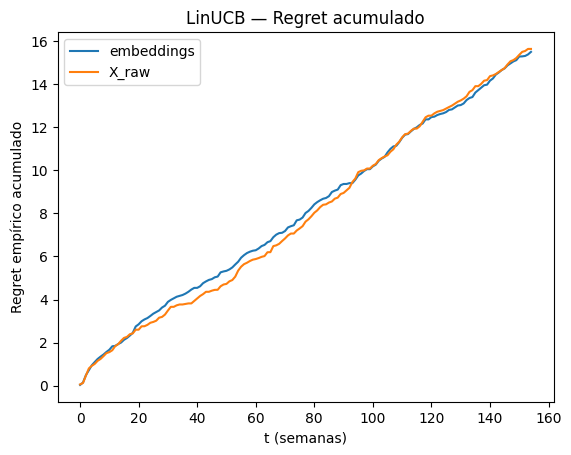

In [65]:
plt.figure()
plt.plot(logs_emb["linucb"]["cum_regret_emp"], label="embeddings")
plt.plot(logs_xraw["linucb"]["cum_regret_emp"], label="X_raw")
plt.xlabel("t (semanas)")
plt.ylabel("Regret empírico acumulado")
plt.title("LinUCB — Regret acumulado")
plt.legend()
plt.savefig(OUT_FIG / "cum_regret_linucb_embeddings_vs_xraw.png", dpi=150, bbox_inches="tight")
plt.show()
